# Ensemble Final — Top-5 do Grupo
## Aplicação de Sistemas Inteligentes — Etapa 5 (Síntese e Ensemble)

Este notebook é executado **depois** que todos os membros rodaram suas variações
e salvaram os modelos em `modelos_salvos/membroN/`.

Fluxo:
1. **Scan** automático de `modelos_salvos/` para listar todos os `.joblib` disponíveis
2. **Selecione manualmente** os 5 melhores (editando `SELECTED_MODELS`)
3. **Inferência** de cada modelo no conjunto de validação (mesmo split usado no treino)
4. **Ensemble** em 3 modalidades:
   - Média simples das probabilidades
   - Média ponderada pelo F1 individual
   - Voto majoritário
5. **Comparação** ensemble vs modelos individuais
6. **Matrizes de confusão** para o relatório final


## 1 · Imports

In [1]:
import os, json, itertools, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import joblib
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score,
)
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")


Device: cuda


## 2 · Configuração do dataset

Mesmo `DATA_ROOT` usado pelos notebooks de treino. O split estratificado
usa `random_state=42` — idêntico aos notebooks individuais — para que o
conjunto de validação seja exatamente o mesmo.

In [2]:
DATA_ROOT = Path("..\\data_sets\\ovarian_ultrasound_dataset")

if not DATA_ROOT.exists():
    raise FileNotFoundError(f"Pasta não encontrada: {DATA_ROOT.resolve()}")

use_predefined_split = (
    (DATA_ROOT / "train").exists() and
    (DATA_ROOT / "validation").exists()
)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

_probe = datasets.ImageFolder(DATA_ROOT / "train" if use_predefined_split else DATA_ROOT)
CLASS_NAMES = _probe.classes
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes: {CLASS_NAMES} ({NUM_CLASSES})")
print(f"Split: {'pré-definido' if use_predefined_split else 'estratificado 80/20 (seed=42)'}")


def make_val_loader(img_size: int, batch_size: int = 16):
    """Cria um loader de validação na resolução desejada para um modelo específico."""
    val_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])
    if use_predefined_split:
        val_ds = datasets.ImageFolder(DATA_ROOT / "validation", transform=val_tfms)
    else:
        full_ds = datasets.ImageFolder(DATA_ROOT)
        targets = [y for _, y in full_ds.samples]
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
        _, val_idx = next(sss.split(np.zeros(len(targets)), targets))
        val_ds_src = datasets.ImageFolder(DATA_ROOT, transform=val_tfms)
        val_ds = Subset(val_ds_src, val_idx)

    nw = min(4, os.cpu_count() or 1) if device.type == "cuda" else 0
    return DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                      num_workers=nw, pin_memory=True)

print("✅ make_val_loader pronto")


Classes: ['Dominant_Follicle', 'Normal', 'PCO'] (3)
Split: estratificado 80/20 (seed=42)
✅ make_val_loader pronto


## 3 · Scan dos modelos salvos

Lista todos os `.joblib` em `modelos_salvos/membro*/`. Use esta saída como
referência para preencher `SELECTED_MODELS` na próxima célula.

In [3]:
SAVE_ROOT = Path("modelos_salvos")

discovered = []
if SAVE_ROOT.exists():
    for member_dir in sorted(SAVE_ROOT.glob("membro*")):
        for f in sorted(member_dir.glob("*.joblib")):
            size_mb = f.stat().st_size / (1024**2)
            discovered.append({"path": f, "member": member_dir.name, "size_mb": size_mb})

if not discovered:
    print("⚠️  Nenhum modelo encontrado em modelos_salvos/. Treine pelo menos algumas variações primeiro.")
else:
    print(f"{'Membro':<10} {'Arquivo':<50} {'Tamanho':>8}")
    print("─" * 72)
    for d in discovered:
        print(f"{d['member']:<10} {d['path'].name:<50} {d['size_mb']:>6.1f}MB")
    print(f"\nTotal: {len(discovered)} modelos disponíveis")


Membro     Arquivo                                             Tamanho
────────────────────────────────────────────────────────────────────────
membro1    membro1_V1_EffNet-B2_frozen.joblib                   29.9MB
membro1    membro1_V2_EffNet-B2_+Dropout.joblib                 29.9MB
membro1    membro1_V3_EffNet-B2_last-block.joblib               32.6MB
membro1    membro1_V4_EffNet-B2_+Scheduler.joblib               32.6MB
membro1    membro1_V5_EffNet-B2_2-blocks.joblib                 34.0MB
membro1    membro1_V6_EffNet-B2_256px.joblib                    35.4MB
membro1    membro1_V7_EffNet-B3_FT+TTA.joblib                   47.4MB
membro1    membro1_V8_EffNet-B3_SE+TTA.joblib                   47.9MB
membro2    membro2_V1_ResNet-50_frozen.joblib                   90.0MB
membro2    membro2_V2_ResNeXt-50_frozen.joblib                  88.1MB
membro2    membro2_V3_ResNet-50_layer4.joblib                   94.0MB
membro2    membro2_V4_ResNet-101_+Scheduler.joblib             166.8MB
memb

## 4 · Seleção dos 5 melhores

**Edite a lista abaixo** com base nos resultados das tabelas finais de cada notebook.
Para cada modelo selecionado, informe:

| Campo | Descrição |
|-------|-----------|
| `name` | Rótulo curto para os gráficos (ex.: `"M1-V7 EffNet-B3"`) |
| `path` | Caminho do `.joblib` (relativo à raiz do projeto) |
| `img_size` | Resolução em que o modelo foi treinado (224 / 256 / 299) |
| `f1` | F1 macro individual reportado no notebook do membro — usado como peso |
| `batch_size` | Opcional. Reduza se o modelo for grande (V8 a 299px → 8 ou 12) |

**Referência rápida de img_size por variação:**

- V1–V5 (todos os membros): **224**
- V6 (todos os membros): **256**
- V7 (todos os membros): **256**
- V8 Membro 1 / 3: **299** · V8 Membro 2 / 4: **256**


In [4]:
SELECTED_MODELS = [
    {"name": "M2_v6", "path": "modelos_salvos/membro2/membro2_V6_ResNeXt-50_256px.joblib",
     "img_size": 256, "f1": 0.888, "batch_size": 16},
    {"name": "M3_v5", "path": "modelos_salvos/membro3/membro3_V5_DN-121_blocks3+4.joblib",
     "img_size": 256, "f1": 0.914, "batch_size": 16},
    {"name": "M3_v6", "path": "modelos_salvos/membro3/membro3_V6_DN-169_256px.joblib",
     "img_size": 256, "f1": 0.902, "batch_size": 16},
    {"name": "M4_v2", "path": "modelos_salvos/membro4/membro4_V2_ConvNeXt-T_frozen.joblib",
     "img_size": 256, "f1": 0.851, "batch_size": 16},
    {"name": "M4_v5", "path": "modelos_salvos/membro4/membro4_V5_ConvNeXt-T_2stages.joblib",
     "img_size": 256, "f1": 0.902, "batch_size": 16},
]

# Validação rápida
for m in SELECTED_MODELS:
    p = Path(m["path"])
    assert p.exists(), f"❌ Arquivo não existe: {p.resolve()}"
print(f"✅ {len(SELECTED_MODELS)} modelos selecionados e arquivos verificados")


✅ 5 modelos selecionados e arquivos verificados


## 5 · Inferência individual

Cada modelo recebe seu próprio loader na resolução em que foi treinado.
Retornamos as probabilidades softmax (B, N_classes) e as classes verdadeiras (B,).

In [5]:
@torch.no_grad()
def predict_proba(model_path: str, img_size: int, batch_size: int = 16):
    """Carrega .joblib, roda no val set, devolve (probs, targets, elapsed_s)."""
    t0 = time.time()
    # joblib.load preserva o device original. Forçamos CPU primeiro e movemos para device atual.
    model = joblib.load(model_path)
    model = model.to(device)
    model.eval()

    loader = make_val_loader(img_size=img_size, batch_size=batch_size)
    all_probs, all_targets = [], []
    for X, y in loader:
        X = X.to(device, non_blocking=True)
        logits = model(X)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_targets.append(y.numpy())

    # libera VRAM
    del model
    if device.type == "cuda":
        torch.cuda.empty_cache()

    probs = np.concatenate(all_probs, axis=0)
    targets = np.concatenate(all_targets, axis=0)
    return probs, targets, time.time() - t0


# Roda inferência para todos os modelos selecionados
all_probs = []      # lista de arrays (N_val, N_classes)
all_targets_ref = None
individual_results = []

for m in SELECTED_MODELS:
    print(f"\n→ {m['name']}  ({Path(m['path']).name})  img_size={m['img_size']}")
    probs, targets, elapsed = predict_proba(m["path"], m["img_size"], m.get("batch_size", 16))
    if all_targets_ref is None:
        all_targets_ref = targets
    else:
        assert np.array_equal(all_targets_ref, targets), \
            "Targets do val set divergiram entre modelos — split inconsistente!"
    preds = probs.argmax(axis=1)
    acc = accuracy_score(targets, preds)
    f1  = f1_score(targets, preds, average="macro", zero_division=0)
    prec = precision_score(targets, preds, average="macro", zero_division=0)
    rec  = recall_score(targets, preds, average="macro", zero_division=0)
    individual_results.append({
        "name": m["name"], "accuracy": acc, "f1_macro": f1,
        "precision": prec, "recall": rec,
        "inference_s": round(elapsed, 1),
    })
    all_probs.append(probs)
    print(f"   acc={acc:.4f}  f1={f1:.4f}  prec={prec:.4f}  rec={rec:.4f}  ({elapsed:.1f}s)")

probs_stack = np.stack(all_probs, axis=0)   # shape: (N_models, N_val, N_classes)
print(f"\nShape do tensor de probabilidades: {probs_stack.shape}")



→ M2_v6  (membro2_V6_ResNeXt-50_256px.joblib)  img_size=256
   acc=0.9016  f1=0.8885  prec=0.9261  rec=0.8635  (6.5s)

→ M3_v5  (membro3_V5_DN-121_blocks3+4.joblib)  img_size=256
   acc=0.9344  f1=0.9014  prec=0.9142  rec=0.8913  (5.6s)

→ M3_v6  (membro3_V6_DN-169_256px.joblib)  img_size=256
   acc=0.9344  f1=0.9025  prec=0.9163  rec=0.8913  (6.4s)

→ M4_v2  (membro4_V2_ConvNeXt-T_frozen.joblib)  img_size=256
   acc=0.8689  f1=0.8512  prec=0.8646  rec=0.8405  (6.4s)

→ M4_v5  (membro4_V5_ConvNeXt-T_2stages.joblib)  img_size=256
   acc=0.9344  f1=0.9018  prec=0.9153  rec=0.8937  (5.9s)

Shape do tensor de probabilidades: (5, 61, 3)


## 6 · Estratégias de ensemble

Calculamos três estratégias canônicas:

1. **Média simples** — `mean(probs)` de todos os modelos
2. **Média ponderada** — `sum(w_i * probs_i)` com `w_i = F1_i / sum(F1)`
3. **Voto majoritário** — cada modelo prediz, contamos o argmax mais frequente

In [6]:
y_true = all_targets_ref

# ─── 1. Média simples ─────────────────────────────────────────────────────
probs_mean = probs_stack.mean(axis=0)
preds_mean = probs_mean.argmax(axis=1)

# ─── 2. Média ponderada pelo F1 individual ────────────────────────────────
weights = np.array([m["f1"] for m in SELECTED_MODELS], dtype=float)
if weights.sum() == 0:
    print("⚠️  F1 weights estão zerados — preencha 'f1' em SELECTED_MODELS.")
    weights = np.ones_like(weights)
weights = weights / weights.sum()
probs_weighted = (probs_stack * weights[:, None, None]).sum(axis=0)
preds_weighted = probs_weighted.argmax(axis=1)

# ─── 3. Voto majoritário ──────────────────────────────────────────────────
all_individual_preds = probs_stack.argmax(axis=2)   # (N_models, N_val)
preds_majority = np.zeros(all_individual_preds.shape[1], dtype=int)
for i in range(all_individual_preds.shape[1]):
    votes = np.bincount(all_individual_preds[:, i], minlength=NUM_CLASSES)
    preds_majority[i] = votes.argmax()

def metrics_block(name, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
    rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
    return {"name": name, "accuracy": acc, "f1_macro": f1, "precision": prec, "recall": rec}

ensemble_results = [
    metrics_block("Ensemble — média simples", preds_mean),
    metrics_block(f"Ensemble — média ponderada (pesos: {weights.round(3).tolist()})", preds_weighted),
    metrics_block("Ensemble — voto majoritário", preds_majority),
]

for r in ensemble_results:
    print(f"\n{r['name']}")
    print(f"  Accuracy : {r['accuracy']:.4f}")
    print(f"  F1 Macro : {r['f1_macro']:.4f}")
    print(f"  Precision: {r['precision']:.4f}")
    print(f"  Recall   : {r['recall']:.4f}")



Ensemble — média simples
  Accuracy : 0.9508
  F1 Macro : 0.9269
  Precision: 0.9630
  Recall   : 0.9052

Ensemble — média ponderada (pesos: [0.199, 0.205, 0.202, 0.191, 0.202])
  Accuracy : 0.9508
  F1 Macro : 0.9269
  Precision: 0.9630
  Recall   : 0.9052

Ensemble — voto majoritário
  Accuracy : 0.9508
  F1 Macro : 0.9142
  Precision: 0.9267
  Recall   : 0.9052


## 7 · Matrizes de confusão

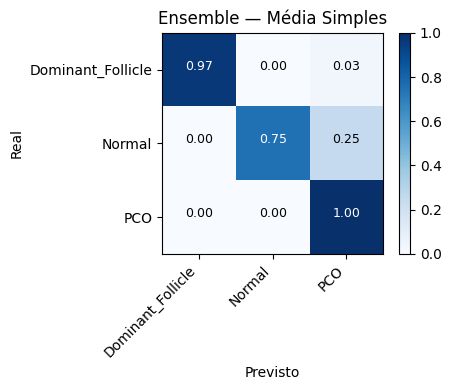

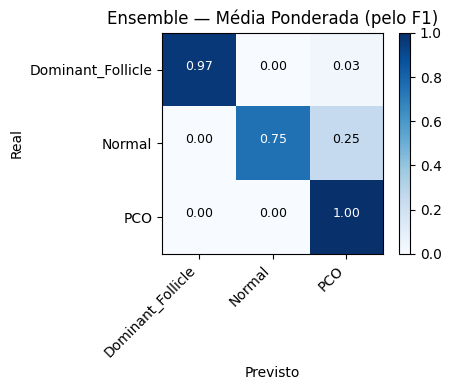

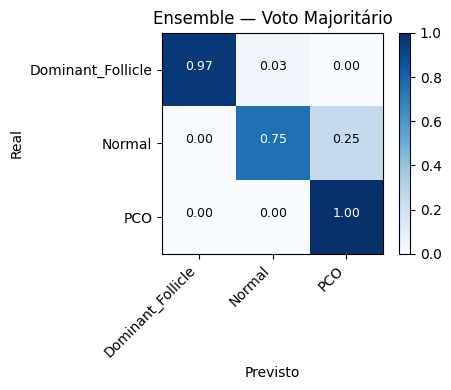

In [7]:
def plot_cm(y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    plt.figure(figsize=(max(5, NUM_CLASSES*1.2), max(4, NUM_CLASSES)))
    plt.imshow(cm_norm, cmap="Blues")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(NUM_CLASSES)
    plt.xticks(ticks, CLASS_NAMES, rotation=45, ha="right")
    plt.yticks(ticks, CLASS_NAMES)
    thresh = cm_norm.max() / 2
    for i, j in itertools.product(range(NUM_CLASSES), range(NUM_CLASSES)):
        plt.text(j, i, f"{cm_norm[i,j]:.2f}", ha="center",
                 color="white" if cm_norm[i,j] > thresh else "black", fontsize=9)
    plt.ylabel("Real"); plt.xlabel("Previsto")
    plt.tight_layout(); plt.show()

plot_cm(preds_mean,     "Ensemble — Média Simples")
plot_cm(preds_weighted, "Ensemble — Média Ponderada (pelo F1)")
plot_cm(preds_majority, "Ensemble — Voto Majoritário")


## 8 · Comparação consolidada

Tabela final no formato exigido pelo PDF (Etapa 5). Inclui cada modelo
individual + as três estratégias de ensemble.

Modelo / Estratégia                                         Acc      F1    Prec     Rec
───────────────────────────────────────────────────────────────────────────────────────
M2_v6                                                    0.9016  0.8885  0.9261  0.8635
M3_v5                                                    0.9344  0.9014  0.9142  0.8913
M3_v6                                                    0.9344  0.9025  0.9163  0.8913
M4_v2                                                    0.8689  0.8512  0.8646  0.8405
M4_v5                                                    0.9344  0.9018  0.9153  0.8937
Ensemble — média simples                                 0.9508  0.9269  0.9630  0.9052
Ensemble — média ponderada (pesos: [0.199, 0.205, 0.202, 0.191, 0.202])  0.9508  0.9269  0.9630  0.9052
Ensemble — voto majoritário                              0.9508  0.9142  0.9267  0.9052

🏆 Melhor F1 Macro: Ensemble — média simples  →  0.9269


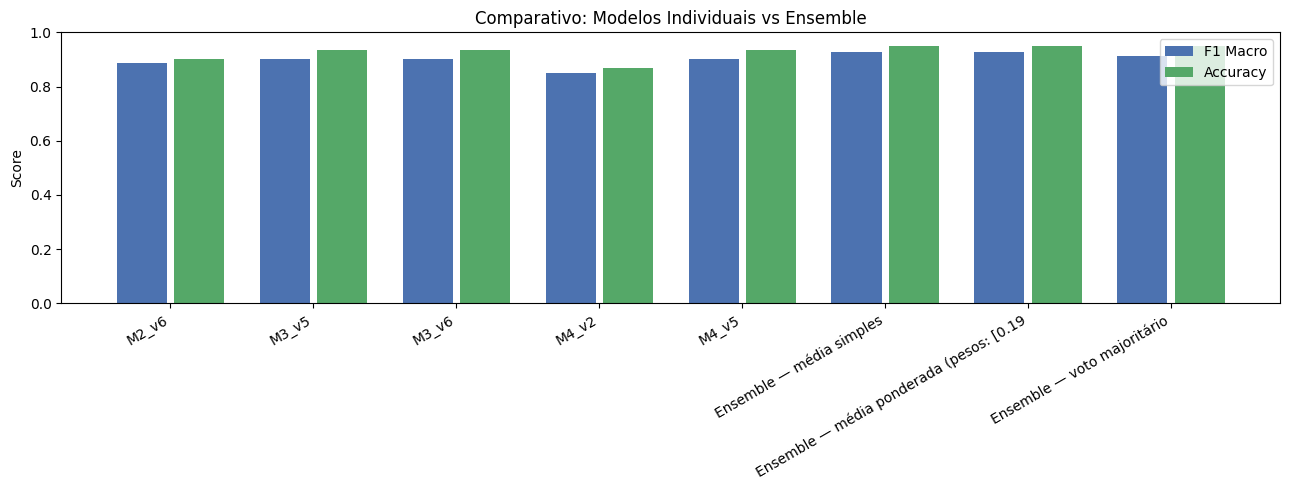

In [8]:
rows = individual_results + ensemble_results

header = f"{'Modelo / Estratégia':<55} {'Acc':>7} {'F1':>7} {'Prec':>7} {'Rec':>7}"
print(header)
print("─" * len(header))
for r in rows:
    print(f"{r['name']:<55} {r['accuracy']:>7.4f} {r['f1_macro']:>7.4f} "
          f"{r['precision']:>7.4f} {r['recall']:>7.4f}")

# Destaca o melhor F1
best = max(rows, key=lambda r: r["f1_macro"])
print(f"\n🏆 Melhor F1 Macro: {best['name']}  →  {best['f1_macro']:.4f}")

# Gráfico de barras comparativo
labels = [r["name"][:40] for r in rows]
f1s    = [r["f1_macro"] for r in rows]
accs   = [r["accuracy"] for r in rows]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 0.2, f1s,  0.35, label="F1 Macro", color="#4C72B0")
ax.bar(x + 0.2, accs, 0.35, label="Accuracy",  color="#55A868")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=30, ha="right")
ax.set_ylim(0, 1); ax.set_ylabel("Score"); ax.legend()
ax.set_title("Comparativo: Modelos Individuais vs Ensemble")
plt.tight_layout(); plt.show()


## 9 · Salvar resultados para o relatório

Gera `ensemble_results.json` com tudo o que o PDF pede na Etapa 5:
modelos incluídos, tipo de ensemble, métricas combinadas, ganho vs melhor individual.

In [9]:
best_individual = max(individual_results, key=lambda r: r["f1_macro"])
best_ensemble   = max(ensemble_results,  key=lambda r: r["f1_macro"])

output = {
    "selected_models": [
        {k: (str(v) if isinstance(v, Path) else v) for k, v in m.items()}
        for m in SELECTED_MODELS
    ],
    "individual_results": individual_results,
    "ensemble_results":   ensemble_results,
    "best_individual":    best_individual,
    "best_ensemble":      best_ensemble,
    "delta_f1":           round(best_ensemble["f1_macro"] - best_individual["f1_macro"], 4),
}

out_path = Path("ensemble_results.json")
with open(out_path, "w", encoding="utf-8") as f:
    json.dump(output, f, indent=2, ensure_ascii=False)

print(f"💾 Resultados salvos em {out_path.resolve()}")
print(f"\nMelhor individual: {best_individual['name']}  →  F1={best_individual['f1_macro']:.4f}")
print(f"Melhor ensemble  : {best_ensemble['name']}  →  F1={best_ensemble['f1_macro']:.4f}")
print(f"Ganho do ensemble: {output['delta_f1']:+.4f}")


💾 Resultados salvos em C:\Users\brian\Desktop\Uni\sistemas_int\ovary\image_augmentation\ensemble_results.json

Melhor individual: M3_v6  →  F1=0.9025
Melhor ensemble  : Ensemble — média simples  →  F1=0.9269
Ganho do ensemble: +0.0244


---
## Para o relatório (Etapa 5 do PDF)

Cole estas informações na seção **Resultados do Ensemble Final**:

- **Modelos incluídos**: copie da lista `SELECTED_MODELS`
- **Tipo de ensemble**: média ponderada pelo F1 macro individual (ou a estratégia vencedora)
- **Métricas combinadas**: ver tabela da Seção 8
- **Matriz de confusão**: ver Seção 7
- **Discussão**: comparar `delta_f1` do JSON acima. Se positivo, o ensemble agregou valor. Se negativo, vale discutir por quê (modelos muito correlacionados, F1s muito desiguais, etc.).
